### 1. Import Libraries and Dataset

In [66]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations

In [67]:
stocks = [
    "AAPL",
    "XOM",
    "JNJ",
    "JPM",
    "PG",
    "CAT",
    "KO",
    "UNH",
    "NVDA",
    "BA"
]
df = yf.download(stocks, start='2025-01-01', end='2025-12-31')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8792\4125142210.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stocks, start='2025-01-01', end='2025-12-31')
[*********************100%***********************]  10 of 10 completed


In [68]:
df = np.log(1 + df['Close'].pct_change())
df = df.dropna()

In [69]:
df.head()

Ticker,AAPL,BA,CAT,JNJ,JPM,KO,NVDA,PG,UNH,XOM
Date,,,,,,,,,,
2025-01-03,-0.002012,-0.011528,0.011112,0.001180,0.013574,-0.001456,0.043574,-0.005134,0.016688,0.005112
2025-01-06,0.006716,0.005166,0.001126,-0.003683,-0.004887,-0.015340,0.033756,-0.027816,0.001305,-0.001113
2025-01-07,-0.011453,0.010079,-0.003300,0.017731,0.009586,0.000493,-0.064186,0.004349,0.001128,0.009331
2025-01-08,0.002021,-0.004357,-0.005331,-0.027454,-0.000165,0.014199,-0.000214,0.004947,0.019774,-0.016877
2025-01-10,-0.024399,0.001396,-0.028286,-0.001477,-0.013499,-0.010425,-0.030435,-0.022080,-0.007329,-0.003654


### 2. Functions

- Portfolio Return = w1 * m1 + w2 * m2
- Portfolio Variance = w1^2 * Cov11^2 + w2^2 * Cov22^2 + 2*w1*w1*Cov12

In [ ]:
# Portfolio Return Function
def portfolioreturn(df, weights):
    return np.dot(df.mean(), weights) * 252

def portfoliostd(df, weights):
    return np.sqrt(
        np.dot(weights.T, np.dot(df.cov(), weights))
    ) * np.sqrt(252)

# Creating random weight distribution function
def randomweights(df):
    rand = np.random.random(len(df.columns))
    rand /= rand.sum()
    return rand

'# Portfolio Variance Function\ndef portfoliostd(df, weights):\n    pv = np.dot(np.dot(df.cov(), weights), weights)**(1/2)*np.sqrt(252)\n    return pv'

### 3. Finding The Best Stock Combination

In [71]:
gmv_list = []
ms_list = []

for i in range(3,6):
    for combo in combinations(stocks, i):
        df_combo = df[list(combo)]

        returns = []
        stds = []
        w = []

        for _ in range(500):
            weights = randomweights(df_combo)
            r = portfolioreturn(df_combo, weights) 
            s = portfoliostd(df_combo, weights)

            returns.append(r)
            stds.append(s)
            w.append(weights)

        # GMV
        i_gmv = np.argmin(stds)
        gmv_list.append([
            returns[i_gmv],
            stds[i_gmv],
            w[i_gmv],
            combo,
            returns,
            stds
        ])

        # Max Sharpe
        rf = 0.063
        sharpes = [(r - rf) / s for r, s in zip(returns, stds)]
        i_ms = np.argmax(sharpes)

        ms_list.append([
            returns[i_ms],
            stds[i_ms],
            w[i_ms],
            combo,
            sharpes[i_ms],
            returns,
            stds
        ])

# Best GMV
best_gmv = min(gmv_list, key=lambda x: x[1])
best_gmv_return  = best_gmv[0]
best_gmv_std     = best_gmv[1]
best_gmv_weights = best_gmv[2]
best_gmv_combo   = best_gmv[3]
best_gmv_returns = best_gmv[4]
best_gmv_stds    = best_gmv[5]
print('Global Minimum Variance Across All Combination')
print(f'Combination: {best_gmv_combo} | Return: {best_gmv_return} | Std: {best_gmv_std} | Weights: {best_gmv_weights}')
print('')

# Best Maximum Sharpe
best_ms = max(ms_list, key=lambda x: x[4])
best_ms_return  = best_ms[0]
best_ms_std     = best_ms[1]
best_ms_weights = best_ms[2]
best_ms_combo   = best_ms[3]
best_ms_sharpe  = best_ms[4]
best_ms_returns = best_ms[5]
best_ms_stds    = best_ms[6]
print('Maximum Sharpe Across All Combination')
print(f'Combination: {best_ms_combo} | Return: {best_ms_return} | Std: {best_ms_std} | Weights: {best_ms_weights} | Sharpe: {best_ms_sharpe}')
print('')

Global Minimum Variance Across All Combination
Combination: ('XOM', 'JNJ', 'KO', 'UNH', 'NVDA') | Return: 0.21537452830962886 | Std: 0.12439372504189407 | Weights: [0.17454913 0.289371   0.34815949 0.05691241 0.13100797]

Maximum Sharpe Across All Combination
Combination: ('JNJ', 'CAT', 'NVDA') | Return: 0.410701968605534 | Std: 0.15977383521668753 | Weights: [0.70038323 0.20723448 0.09238229] | Sharpe: 2.1762134465507175



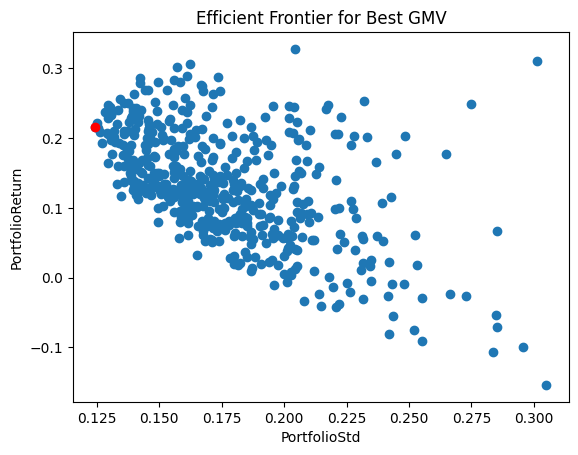

In [72]:
plt.scatter(best_gmv_stds, best_gmv_returns)
plt.scatter(best_gmv_std, best_gmv_return, c = 'red')
plt.title("Efficient Frontier for Best GMV")
plt.xlabel("PortfolioStd")
plt.ylabel("PortfolioReturn")
plt.show()

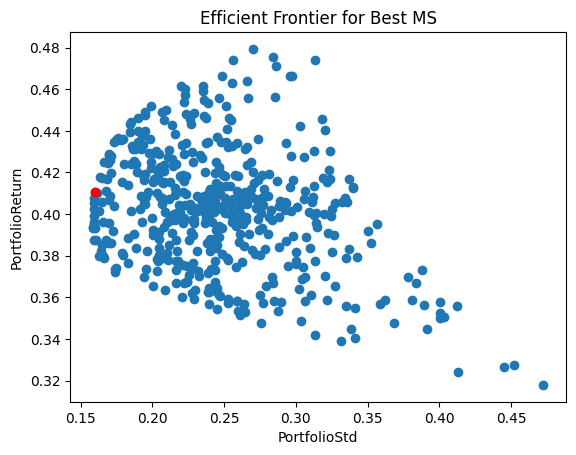

In [73]:
plt.scatter(best_ms_stds, best_ms_returns)
plt.scatter(best_ms_std, best_ms_return, c = 'red')
plt.title("Efficient Frontier for Best MS")
plt.xlabel("PortfolioStd")
plt.ylabel("PortfolioReturn")
plt.show()